## Simple Neural ODE 

In [116]:
import time

import jax
import jax.numpy as jnp
import jax.nn as jnn
import jax.random as jr
from diffrax import backward_hermite_coefficients, CubicInterpolation
from jaxtyping import Array, PRNGKeyArray
from typing import Callable

import diffrax
import equinox as eqx

import optax


from functools import partial

import numpy as np
import matplotlib.pyplot as plt

In [135]:
# Load the data
data = jnp.load('juggle_data.npz')
ts = data['ts']       # shape: (T,)
us = data['us']       # shape: (N, T, DOF)
qs = data['qs']       # shape: (N, T, DOF)
qs_t = data['qs_t']   # shape: (N, T, DOF)
qs_tt = data['qs_tt'] # shape: (N, T, DOF)

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)

T_total = ts.shape[0]
T_cut = int(0.5 * T_total)

ts = ts[:T_cut]
us = us[:, :T_cut, :]
qs = qs[:, :T_cut, :]
qs_t = qs_t[:, :T_cut, :]
qs_tt = qs_tt[:, :T_cut, :]

print("ts shape:", ts.shape)
print("us shape:", us.shape)
print("qs shape:", qs.shape)



ts shape: (5001,)
us shape: (50, 5001, 4)
qs shape: (50, 5001, 4)
ts shape: (2500,)
us shape: (50, 2500, 4)
qs shape: (50, 2500, 4)


In [136]:
# Data Standardization method  1 (each degree of freedom has own value)
''''qs_mean, qs_std = jnp.mean(qs, axis=(0,1)), jnp.std(qs, axis=(0,1))
qs_t_mean, qs_t_std = jnp.mean(qs_t, axis=(0,1)), jnp.std(qs_t, axis=(0,1))
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt, axis=(0,1)), jnp.std(qs_tt, axis=(0,1))
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))'''


# Data Standardization method  2 (all degrees of freedom together)
qs_mean, qs_std = jnp.mean(qs), jnp.std(qs)
qs_t_mean, qs_t_std = jnp.mean(qs_t), jnp.std(qs_t)
qs_tt_mean, qs_tt_std = jnp.mean(qs_tt), jnp.std(qs_tt)
us_mean, us_std = jnp.mean(us, axis=(0,1)), jnp.std(us, axis=(0,1))

print ("Standardization data:")
print ("degree_mean:",qs_mean, "degree_std:",qs_std)
print ("velocity_mean:",qs_t_mean, "velocity_std:",qs_t_std)
print ("acceleration_mean:",qs_tt_mean, "acceleration_std:",qs_tt_std)
print ("torque_mean:",us_mean, "torque_std:",us_std)




Standardization data:
degree_mean: 0.53545207 degree_std: 0.55542237
velocity_mean: 0.00019829102 velocity_std: 1.3415383
acceleration_mean: 0.06515807 acceleration_std: 19.734734
torque_mean: [-0.17494874 -4.3679194   0.04430274 -1.5036372 ] torque_std: [ 7.8457475 26.273884   2.3094869  9.124658 ]


In [137]:
# Number of training,validation,test trajectories
n_train = 40    
n_validation = 5 # first 5 trajectory


qs_train = qs[n_validation:n_train+n_validation ]
qs_t_train = qs_t[n_validation:n_train+n_validation ]
qs_tt_train = qs_tt[n_validation:n_train+n_validation ]
us_train = us[n_validation:n_train+n_validation]

qs_test = qs[n_train+n_validation :]
qs_t_test = qs_t[n_train+n_validation :]
qs_tt_test = qs_tt[n_train+n_validation :]
us_test = us[n_train+n_validation:]

qs_val = qs[:n_validation]
qs_t_val = qs_t[:n_validation]
qs_tt_val = qs_tt[:n_validation]
us_val = us[:n_validation]




qs_train_std = (qs_train - qs_mean) / qs_std           
qs_t_train_std = qs_t_train / qs_t_std
qs_tt_train_std = qs_tt_train * qs_std / (qs_t_std **2)
us_train_std =((us_train - us_mean) / us_std ) 

qs_val_std = (qs_val - qs_mean) / qs_std           
qs_t_val_std = qs_t_val / qs_t_std
qs_tt_val_std = qs_tt_val * qs_std / (qs_t_std **2)
us_val_std =((us_val - us_mean) / us_std ) 

t_scale = (qs_t_std/ qs_std)* ts






In [138]:
print ("after rescaling the data:")
print ("degree_mean:",jnp.mean(qs_train_std, axis=(0,1)), "degree_std:",jnp.std(qs_train_std, axis=(0,1)))
print ("velocity_mean:",jnp.mean(qs_t_train_std, axis=(0,1)), "velocity_std:",jnp.std(qs_t_train_std, axis=(0,1)))
print ("acceleration_mean:",jnp.mean(qs_tt_train_std, axis=(0,1)), "acceleration_std:",jnp.std(qs_tt_train_std, axis=(0,1)))

print ("intial timescale", ts[1] - ts[0] )
print ("new timescale:" , t_scale[1] - t_scale[0])


after rescaling the data:
degree_mean: [-0.9626594  0.8976989 -0.9617575  1.0303117] degree_std: [0.2742734  0.28237432 0.18860658 0.30123672]
velocity_mean: [ 5.4265573e-03  2.9360857e-03  5.6892317e-05 -9.5472327e-03] velocity_std: [0.73624027 1.1524454  0.4384215  1.3717664 ]
acceleration_mean: [-0.0509753   0.06926854  0.01449683  0.04580718] acceleration_std: [2.3885217 6.375852  1.767908  9.920423 ]
intial timescale 0.002
new timescale: 0.004830696


# Solve the problem with Neural ODE + Manual ODE solving

### inputs [q , q_t]

### control [u]

### output [q_t , q_tt]

In [141]:
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP
    solver: diffrax.AbstractSolver
    stepsize_controller: diffrax.AbstractStepSizeController
    state_size: int
    control_size: int
    output_size: int

    def __init__(
        self, 
        state_size: int = 8,       # 4 degree + 4 velocity
        control_size: int= 4,       # 4 torque
        output_size: int = 8,      # 4 velocity + 4 acceleration 
        nn_width: int = 64,
        nn_depth: int = 3,
        *,
        key: PRNGKeyArray,
        solver: diffrax.AbstractSolver = diffrax.Tsit5(),
        #solver: diffrax.AbstractSolver = diffrax.Euler(),
        stepsize_controller: diffrax.AbstractStepSizeController = diffrax.PIDController(rtol=1e-3, atol=1e-6),
    ):
        super().__init__()
        self.state_size = state_size
        self.control_size = control_size
        self.output_size = output_size
        self.solver = solver
        self.stepsize_controller = stepsize_controller


        self.mlp = eqx.nn.MLP(
            in_size=state_size + control_size,
            out_size=output_size,
            width_size=nn_width,
            depth=nn_depth,
            activation=jnn.softplus,
            #final_activation=jnn.tanh,
            key=key
        )

    def __call__(self ,y: Array , u:Array) -> Array:
        """Predict dy/dt given state y and control u"""
        MAX_ACC = 1
        input = jnp.concatenate([y,u] , axis=-1)
        return MAX_ACC*self.mlp(input)  

In [142]:
def _dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = min(batch_size, dataset_size)
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size
@eqx.filter_value_and_grad                    
def grad_loss(model, batch_X, batch_y_t):
    y = batch_X[:, :8]   # q and q̇
    u = batch_X[:, 8:]   # control inputs
    y_t_pred = jax.vmap(model)(y, u)
    return jnp.mean((batch_y_t - y_t_pred) ** 2)

@eqx.filter_jit
def val_loss(model, batch_X, batch_y_t):
    y = batch_X[:, :8]   # q and q̇
    u = batch_X[:, 8:]   # control inputs
    y_t_pred = jax.vmap(model)(y, u)
    return jnp.mean((batch_y_t - y_t_pred) ** 2)

@eqx.filter_jit                                 
def make_step(batch_X, batch_y_t, model, optim, opt_state):
    loss, grads = grad_loss(model, batch_X, batch_y_t)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

def train(
    model, training_data,val_data,
    *, key,
    batch_size=64,
    lr=1e-4,
    steps=1000,
    print_every=100,
    ):

    y, y_t = training_data
    y_val, y_t_val = val_data

    losses = []
    val_losses = []

    start_time = time.time()
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
    for step, (_y, _y_t) in zip(
        range(steps), _dataloader((y, y_t), batch_size, key=key)
    ):
        loss, model, opt_state = make_step(_y, _y_t, model, optim, opt_state)
        losses.append(loss)
        if (step % print_every) == 0 or step == steps - 1:
            vloss = val_loss(model, y_val, y_t_val)
            val_losses.append(vloss)
            print(f"Step: {step}, Loss: {loss:.3e}, validation: {vloss:.3e}")
    training_time = time.time() - start_time
    print(f'Training took: {training_time:-2f}s')

    return model, losses, val_losses

In [143]:
N, T, DOF = qs.shape

#Reshape to (N*T, DOF) for derivative fitting (training)
qs_flat = qs_train_std.reshape(-1, DOF)       # (N*T, 4)
qs_t_flat = qs_t_train_std.reshape(-1, DOF)   # (N*T, 4)
qs_tt_flat = qs_tt_train_std.reshape(-1, DOF) # (N*T, 4)
us_flat = us_train_std.reshape(-1, DOF)       # (N*T, 4)

x_train = jnp.concatenate([qs_flat, qs_t_flat, us_flat], axis=-1) # input [q , q_t , u]
y_train = jnp.concatenate( [qs_t_flat,qs_tt_flat], axis=-1) # output  [q_t,q_tt]

derivative_data_train = (x_train, y_train) 

print(derivative_data_train[0].shape)
print(derivative_data_train[1].shape)



#Reshape to (N*T, DOF) for derivative fitting (validation)
qs_flat = qs_val_std.reshape(-1, DOF)       # (N*T, 4)
qs_t_flat = qs_t_val_std.reshape(-1, DOF)   # (N*T, 4)
qs_tt_flat = qs_tt_val_std.reshape(-1, DOF) # (N*T, 4)
us_flat = us_val_std.reshape(-1, DOF)       # (N*T, 4)

x_val = jnp.concatenate([qs_flat, qs_t_flat, us_flat], axis=-1)
y_val = jnp.concatenate( [qs_t_flat,qs_tt_flat], axis=-1) 

derivative_data_val = (x_val, y_val) 

print(derivative_data_val[0].shape)
print(derivative_data_val[1].shape)


(100000, 12)
(100000, 8)
(12500, 12)
(12500, 8)


In [144]:
import time
key = jr.key(0)

model_key, loader_key = jr.split(key, 2)

nn = NeuralODE(state_size=8, control_size=4, output_size=8, key=model_key)


In [145]:
nn, losses,val_loss= train(nn, derivative_data_train,derivative_data_val, key=loader_key, steps=30000,print_every=500)

Step: 0, Loss: 1.988e+01, validation: 1.977e+01
Step: 500, Loss: 3.409e+00, validation: 4.595e+00
Step: 1000, Loss: 3.197e+00, validation: 3.167e+00
Step: 1500, Loss: 1.619e+00, validation: 2.259e+00
Step: 2000, Loss: 1.865e+00, validation: 1.896e+00
Step: 2500, Loss: 2.097e+00, validation: 1.759e+00
Step: 3000, Loss: 1.152e+00, validation: 1.666e+00
Step: 3500, Loss: 1.315e+00, validation: 1.584e+00
Step: 4000, Loss: 1.151e+00, validation: 1.500e+00
Step: 4500, Loss: 1.623e+00, validation: 1.401e+00
Step: 5000, Loss: 1.138e+00, validation: 1.288e+00
Step: 5500, Loss: 1.047e+00, validation: 1.157e+00
Step: 6000, Loss: 7.845e-01, validation: 1.011e+00
Step: 6500, Loss: 6.624e-01, validation: 9.013e-01
Step: 7000, Loss: 7.602e-01, validation: 8.074e-01
Step: 7500, Loss: 4.812e-01, validation: 7.358e-01
Step: 8000, Loss: 5.186e-01, validation: 6.493e-01
Step: 8500, Loss: 5.004e-01, validation: 5.873e-01
Step: 9000, Loss: 3.050e-01, validation: 5.363e-01
Step: 9500, Loss: 3.168e-01, valida

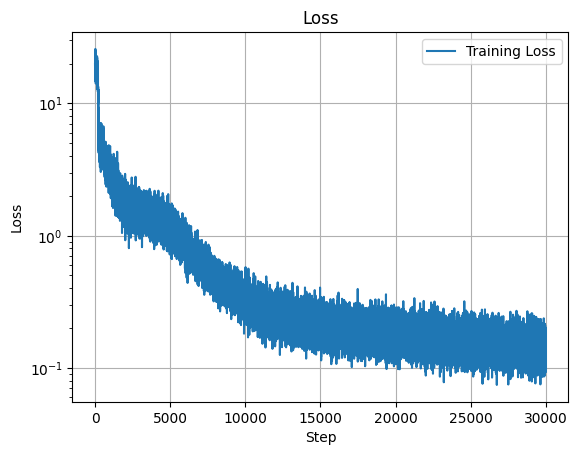

In [146]:
plt.semilogy(losses, label='Training Loss')
# plt.semilogy(val_losses, label='Validation Loss')
plt.title('Loss'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.grid(); plt.legend(); plt.show()

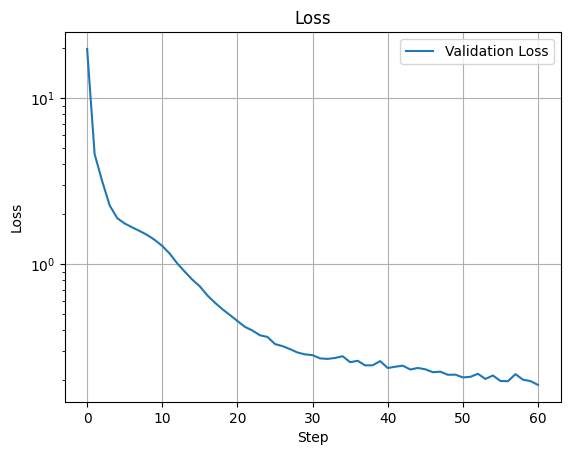

In [147]:
plt.semilogy(val_loss, label='Validation Loss')
plt.title('Loss'); plt.xlabel('Step'); plt.ylabel('Loss'); plt.grid(); plt.legend(); plt.show()

In [148]:
y0_test = jnp.concatenate([qs_test[:, 0, :], qs_t_test[:, 0, :]], axis=-1) 
us_test = us_test  

i = 3
D = 4
# Initial states should be standardized
q0_std = (y0_test[i, :D] - qs_mean) / qs_std
q0_t_std = y0_test[i, D:2*D] / qs_t_std
print (q0_std)
print (q0_t_std)
y0_norm = jnp.concatenate([q0_std, q0_t_std]) 


# Controls should be standardized and stay standardized as input to the NN
us_std_test = ((us_test[i] - us_mean) / us_std )#* (qs_t_std / qs_std)
print (us_std_test)


[-1.144088    1.0524386  -0.96404487  1.3405076 ]
[0. 0. 0. 0.]
[[ 0.02229854  0.16624567 -0.01918294  0.16478834]
 [ 0.02229854  0.16624567 -0.01918294  0.16478834]
 [ 0.03453667  0.16239628 -0.1322415   0.1373637 ]
 ...
 [-0.8781637  -0.8632813   0.7845709  -0.7101799 ]
 [-0.86951214 -0.87129617  0.7791044  -0.717848  ]
 [-0.8604863  -0.8787405   0.77341825 -0.7250104 ]]


In [149]:
def Runge_Kutta(nn, q0, q0_t, us, dt):
    qs = [q0]
    qs_t = [q0_t]
    qs_tt = []

    q = q0
    q_t = q0_t

    for u in us:
        def f(state):
            q, q_t = state
            x = jnp.concatenate([q, q_t])
            result= nn(x,u)
            q_t = result[:4]
            q_tt = result[4:]
            return (q_t, q_tt)  

        # Compute RK4 stages
        k1_q, k1_qt = f((q, q_t))
        k2_q, k2_qt = f((q + 0.5*dt*k1_q, q_t + 0.5*dt*k1_qt))
        k3_q, k3_qt = f((q + 0.5*dt*k2_q, q_t + 0.5*dt*k2_qt))
        k4_q, k4_qt = f((q + dt*k3_q, q_t + dt*k3_qt))

        q = q + (dt/6)*(k1_q + 2*k2_q + 2*k3_q + k4_q)
        q_t = q_t + (dt/6)*(k1_qt + 2*k2_qt + 2*k3_qt + k4_qt)

        x = jnp.concatenate([q, q_t])
        result = nn(x,u)  
        q_tt = result[4:]
        qs.append(q)
        qs_t.append(q_t)
        qs_tt.append(q_tt)

    return jnp.stack(qs[:-1]), jnp.stack(qs_t[:-1]), jnp.stack(qs_tt)

In [150]:
dt = t_scale[1] - t_scale[0]
ys_pred_std , ys_t_pred_std , ys_tt_pred_std   = Runge_Kutta(nn, q0_std,q0_t_std,us_std_test,dt)

In [151]:
# DE-Standardization of prediction to compare with true test value
q_pred = ys_pred_std * qs_std + qs_mean
q_tt_pred = (ys_tt_pred_std *(qs_t_std**2)) / qs_std


In [152]:
q_true = qs_test[i]
q_tt_true = qs_tt_test[i]


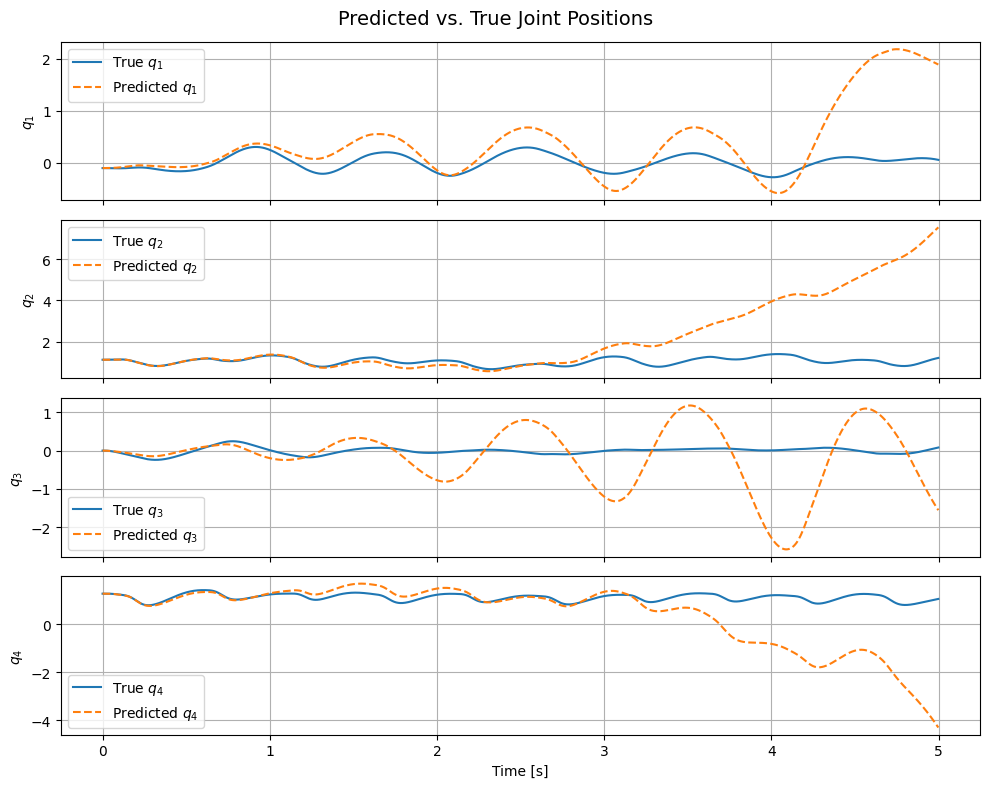

In [153]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for j in range(4):
    axs[j].plot(ts[:], q_true[:, j], label=f"True $q_{j+1}$")
    axs[j].plot(ts[:], q_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    axs[j].set_ylabel(f"$q_{j+1}$")
    axs[j].legend()
    axs[j].grid(True)

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Predicted vs. True Joint Positions", fontsize=14)
plt.tight_layout()
plt.show()


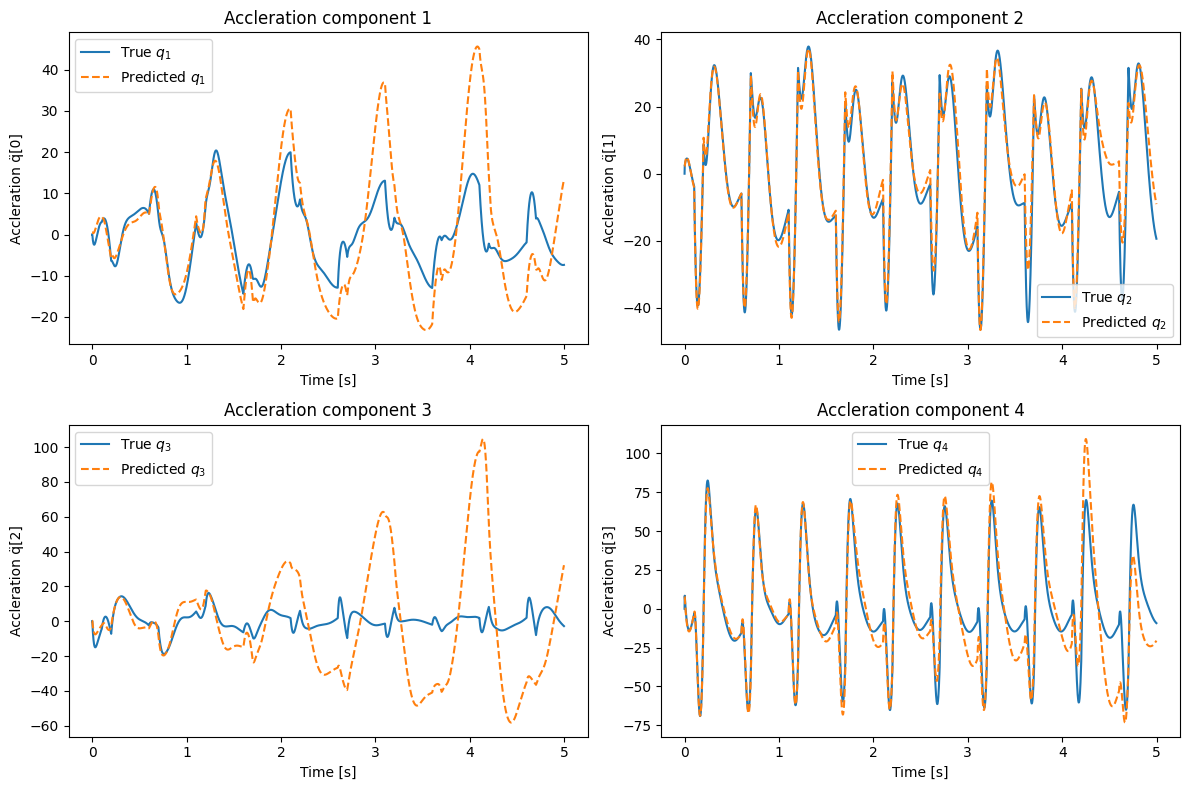

In [154]:
plt.figure(figsize=(12, 8))

for j in range(4):
    plt.subplot(2, 2, j+1)
    plt.plot(ts[:], q_tt_true[:, j], label=f"True $q_{j+1}$")
    plt.plot(ts[:], q_tt_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    plt.xlabel("Time [s]")
    plt.ylabel(f"Accleration q̈[{j}]")
    plt.legend()
    plt.title(f"Accleration component {j+1}")


plt.tight_layout()
plt.show()





# Solve the problem with Neural ODE + ODE SOLVER

### inputs [q , q_t]

### control [u]

### output [q_t , q_tt]

In [155]:
class ODESolver(eqx.Module):
    derivative_model: eqx.Module
    solver: diffrax.AbstractSolver
    stepsize_controller: diffrax.AbstractStepSizeController 
    max_steps: int 

    def __init__(self, 
                 derivative_model: eqx.Module, 
                 *, 
                 solver: diffrax.AbstractSolver = diffrax.Tsit5(),
                 stepsize_controller: diffrax.AbstractStepSizeController = diffrax.PIDController(rtol=1e-6, atol=1e-6),
                 max_steps: int = 4096):
        """Numerically solve the ODE `dy_dt = derivative_model(y, u(t))`."""
        super().__init__()
        self.derivative_model = derivative_model
        self.solver = solver
        self.stepsize_controller = stepsize_controller
        self.max_steps = max_steps

    def __call__(self, ts: Array, y0: Array, us: Array | None) -> Array:
        """Solve the ODE and return the solution without augmented dims."""
        return self._solve(ts, y0, us).ys

    def _solve(self, ts: Array, y0: Array, us: Array | None) -> diffrax.Solution:
        """Run the solver and return the full Diffrax solution."""

        # Interpolate inputs if available
        if us is not None:
            coeffs = backward_hermite_coefficients(ts, us)
            u_interp = CubicInterpolation(ts, coeffs)
        else:
            u_interp = None

        # Define ODE function
        def func(t, y, u_interp):
            if u_interp is None:
                u = None
            else:
                u = u_interp.evaluate(t)
            return self.derivative_model(y,u)
        
        # Solve ODE
        solution = diffrax.diffeqsolve(
            diffrax.ODETerm(func),
            self.solver,
            t0=ts[0], t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=u_interp,
            saveat=diffrax.SaveAt(ts=ts),
            stepsize_controller=self.stepsize_controller,
            max_steps=self.max_steps,
        )

        return solution


In [156]:
nn_ode = ODESolver(nn)
print (t_scale.shape)
print (y0_norm.shape)
print (us_std_test.shape)

ys_pred_std= nn_ode(t_scale,y0_norm,us_std_test)
print (ys_pred_std.shape)

q_pred_std = ys_pred_std[:,:D]
q_pred = (q_pred_std * qs_std) + qs_mean


(2500,)
(8,)
(2500, 4)
(2500, 8)


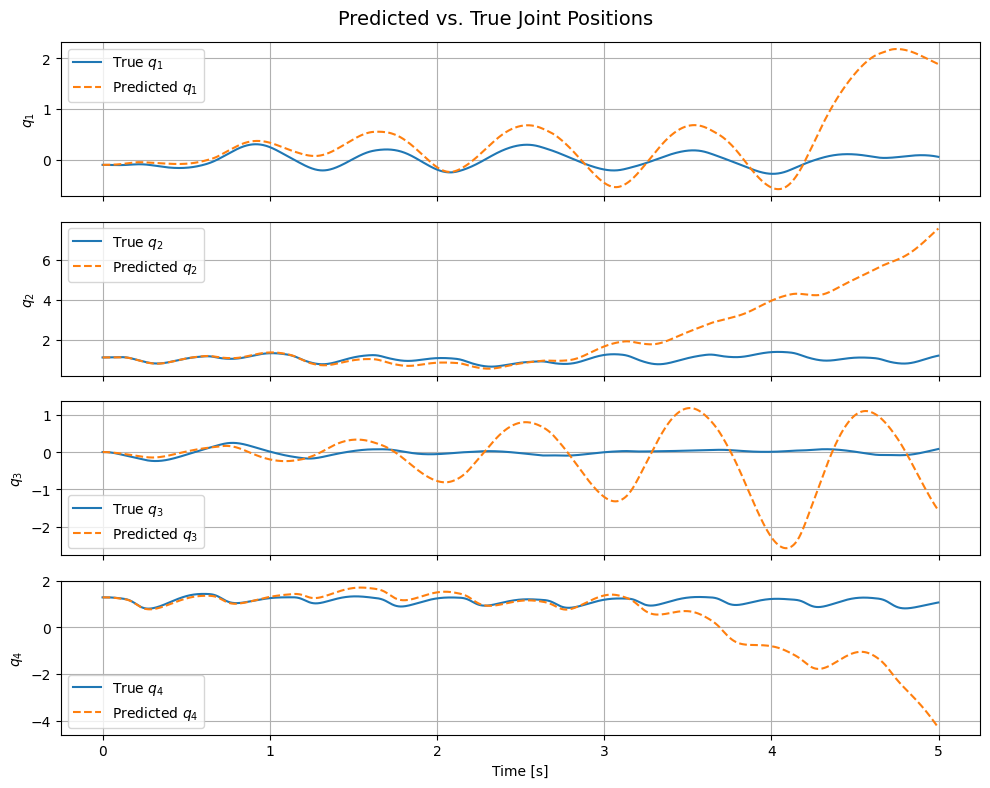

In [157]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

for j in range(4):
    axs[j].plot(ts[:], q_true[:, j], label=f"True $q_{j+1}$")
    axs[j].plot(ts[:], q_pred[:, j], '--', label=f"Predicted $q_{j+1}$")
    axs[j].set_ylabel(f"$q_{j+1}$")
    axs[j].legend()
    axs[j].grid(True)

axs[-1].set_xlabel("Time [s]")
fig.suptitle("Predicted vs. True Joint Positions", fontsize=14)
plt.tight_layout()
plt.show()

# Adding Trajectory fitting as secondary methods for training

In [100]:
import dynax
import klax

In [94]:
def _dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = min(batch_size, dataset_size)
        while end <= dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


@ eqx.filter_value_and_grad
def grad_loss (model, ti, yi, ui):
    y_pred = jax.vmap(model, in_axes = (None,0,0))(ti, yi[: ,0],ui)
    return jnp.mean((yi - y_pred)**2)

@eqx.filter_jit
def make_step (ti,yi,ui,model,optim,opt_state):
    loss,grad = grad_loss (model, ti , yi , ui)
    updates, opt_state = optim.update(grad, opt_state)
    model= eqx.apply_updates(model,updates)
    return loss,model,opt_state

def traj_train (
        model, training_data,*, key, batch_size =32,lr=1e-4,steps=1000,print_every= 100
):
    ts, ys, us= training_data
    losses = []
    start_time = time.time() 
    optim = optax.adabelief(lr)
    opt_state = optim.init(eqx.filter(model, eqx.is_inexact_array))
    data_loader = _dataloader((ys, us), batch_size, key=key)
    for step in range(steps): 
        batch_ys, batch_us = next(data_loader) 
        loss, model, opt_state = make_step(ts, batch_ys, batch_us, model, optim, opt_state)
        losses.append(loss)
        if (step % print_every) == 0 or step == steps - 1: 
            print(f"Step: {step}, Loss: {loss:.3e}")
        training_time = time.time() - start_time
        print(f'Training took: {training_time:-2f}s')

    return model, losses

In [95]:
trajectory_data =(t_scale,jnp.concatenate([qs_train_std, qs_t_train_std], axis=-1),us_train_std)
nn_ode, losses = traj_train(
    nn_ode,trajectory_data,
    steps=5_000,key=loader_key, lr=1e-4
)

TypeError: Argument 'Zero(ShapedArray(float0[32]))' of type '<class 'jax._src.ad_util.Zero'>' is not a valid JAX type